FINAL IMAGE RECOGNITION SYSTEM
Animals vs Vehicles vs Buildings

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar100.load_data(
    label_mode='fine'
)

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Testing images:", x_test.shape)
print("Testing labels:", y_test.shape)

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 2110s 12us/step
Training images: (50000, 32, 32, 3)
Training labels: (50000, 1)
Testing images: (10000, 32, 32, 3)
Testing labels: (10000, 1)


In [ ]:
class_names = [
    'apple', 'aquarium_fish', 'baby', 'bear', 'beaver',
    'bed', 'bee', 'beetle', 'bicycle', 'bottle',
    'bowl', 'boy', 'bridge', 'bus', 'butterfly',
    'camel', 'can', 'castle', 'caterpillar', 'cattle',
    'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach',
    'couch', 'crab', 'crocodile', 'cup', 'dinosaur',
    'dolphin', 'elephant', 'flatfish', 'forest', 'fox',
    'girl', 'hamster', 'house', 'kangaroo', 'keyboard',
    'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard',
    'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain',
    'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid',
    'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree',
    'plain', 'plate', 'poppy', 'porcupine', 'possum',
    'rabbit', 'raccoon', 'ray', 'road', 'rocket',
    'rose', 'sea', 'seal', 'shark', 'shrew',
    'skunk', 'skyscraper', 'snail', 'snake', 'spider',
    'squirrel', 'streetcar', 'sunflower', 'sweet_pepper',
    'table', 'tank', 'telephone', 'television', 'tiger',
    'tractor', 'train', 'trout', 'tulip', 'turtle',
    'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman',
    'worm'
]

animal_classes = ['bear', 'dolphin', 'fox', 'tiger', 'wolf']
vehicle_classes = ['bicycle', 'bus', 'motorcycle', 'pickup_truck', 'train']
building_classes = ['castle', 'house', 'skyscraper']

animal_ids = [class_names.index(x) for x in animal_classes]
vehicle_ids = [class_names.index(x) for x in vehicle_classes]
building_ids = [class_names.index(x) for x in building_classes]

print("Animal IDs:", animal_ids)
print("Vehicle IDs:", vehicle_ids)
print("Building IDs:", building_ids)

Animal IDs: [3, 30, 34, 88, 97]
Vehicle IDs: [8, 13, 48, 58, 90]
Building IDs: [17, 37, 76]


In [ ]:
selected_classes = {
    0: animal_ids[:3],
    1: vehicle_ids[:3],
    2: building_ids
}

category_names = ['Animals', 'Vehicles', 'Buildings']

def create_category_dataset(images, labels):
    X = []
    y = []

    for new_label, class_ids in selected_classes.items():
        for class_id in class_ids:
            indices = np.where(labels.flatten() == class_id)[0]
            X.append(images[indices])
            y.extend([new_label] * len(indices))

    X = np.concatenate(X)
    y = np.array(y)

    return X, y

X_train, Y_train = create_category_dataset(x_train, y_train)
X_test, Y_test = create_category_dataset(x_test, y_test)

print("Training dataset:", X_train.shape)
print("Training labels:", Y_train.shape)
print("Testing dataset:", X_test.shape)
print("Testing labels:", Y_test.shape)

for i, name in enumerate(category_names):
    print(name, "training images:", np.sum(Y_train == i))
    print(name, "testing images:", np.sum(Y_test == i))

Training dataset: (4500, 32, 32, 3)
Training labels: (4500,)
Testing dataset: (900, 32, 32, 3)
Testing labels: (900,)
Animals training images: 1500
Animals testing images: 300
Vehicles training images: 1500
Vehicles testing images: 300
Buildings training images: 1500
Buildings testing images: 300


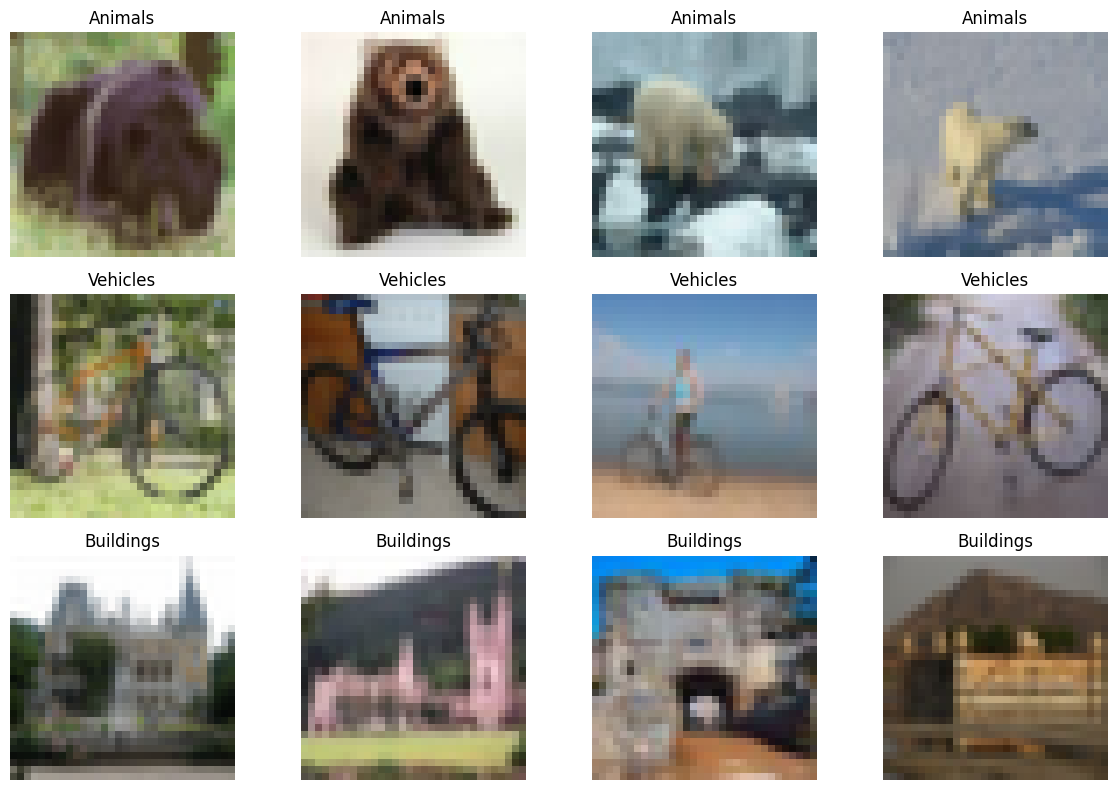

In [ ]:
plt.figure(figsize=(12, 8))

for category in range(3):
    indices = np.where(Y_train == category)[0][:4]

    for j, idx in enumerate(indices):
        position = category * 4 + j + 1
        plt.subplot(3, 4, position)
        plt.imshow(X_train[idx])
        plt.title(category_names[category])
        plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

print("Minimum pixel value:", X_train.min())
print("Maximum pixel value:", X_train.max())
print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Minimum pixel value: 0.0
Maximum pixel value: 1.0
Training shape: (4500, 32, 32, 3)
Testing shape: (900, 32, 32, 3)


In [ ]:
from tensorflow.keras import models, layers

model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(64, activation='relu'),
    layers.Dense(3, activation='softmax')
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,107 (652.76 KB)

 Trainable params: 167,107 (652.76 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully.")

Model compiled successfully.


In [ ]:
history = model.fit(
    X_train,
    Y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 6s 80ms/step - accuracy: 0.5186 - loss: 0.8997 - val_accuracy: 0.0800 - val_loss: 2.2961
Epoch 2/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 6s 104ms/step - accuracy: 0.7278 - loss: 0.6402 - val_accuracy: 0.3011 - val_loss: 2.3785
Epoch 3/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 9s 78ms/step - accuracy: 0.8017 - loss: 0.5146 - val_accuracy: 0.2556 - val_loss: 2.8971
Epoch 4/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 6s 98ms/step - accuracy: 0.8361 - loss: 0.4279 - val_accuracy: 0.3167 - val_loss: 2.4481
Epoch 5/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 10s 94ms/step - accuracy: 0.8617 - loss: 0.3649 - val_accuracy: 0.5222 - val_loss: 1.5030
Epoch 6/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 9s 74ms/step - accuracy: 0.8544 - loss: 0.3857 - val_accuracy: 0.3078 - val_loss: 2.5212
Epoch 7/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 6s 103ms/step - accuracy: 0.8728 - loss: 0.3393 - val_accuracy: 0.4944 - val_loss: 1.9093
Epoch 8/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 74ms/step - accuracy: 0.8719 - loss: 0.3525 - val_accuracy: 0.4322 

In [ ]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    Y_test,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Accuracy (%):", test_accuracy * 100)

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.7811 - loss: 0.7288
Test Loss: 0.728783369064331
Test Accuracy: 0.7811111211776733
Test Accuracy (%): 78.11111211776733


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

Y_pred = model.predict(X_test)
Y_pred_classes = np.argmax(Y_pred, axis=1)

print(classification_report(
    Y_test,
    Y_pred_classes,
    target_names=category_names
))

29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step
              precision    recall  f1-score   support

     Animals       0.68      0.95      0.79       300
    Vehicles       0.87      0.78      0.83       300
   Buildings       0.86      0.61      0.71       300

    accuracy                           0.78       900
   macro avg       0.80      0.78      0.78       900
weighted avg       0.80      0.78      0.78       900



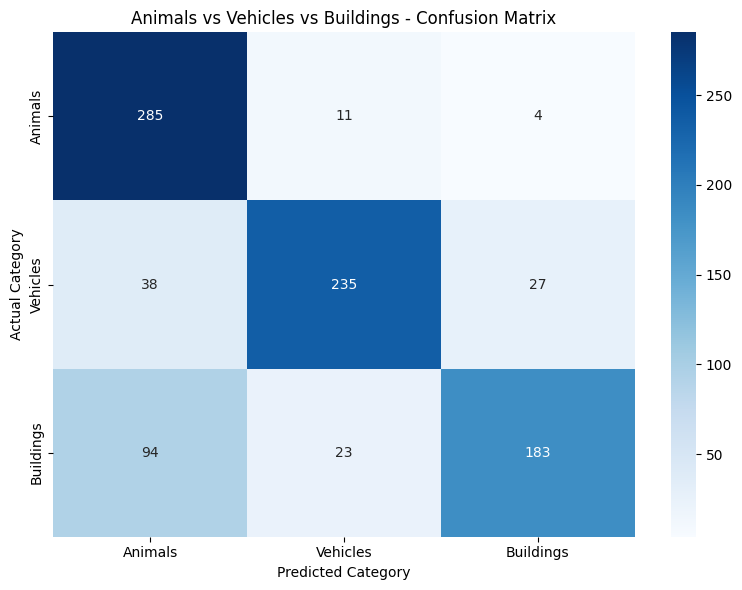

In [ ]:
cm = confusion_matrix(Y_test, Y_pred_classes)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=category_names,
    yticklabels=category_names
)

plt.xlabel('Predicted Category')
plt.ylabel('Actual Category')
plt.title('Animals vs Vehicles vs Buildings - Confusion Matrix')
plt.tight_layout()
plt.show()

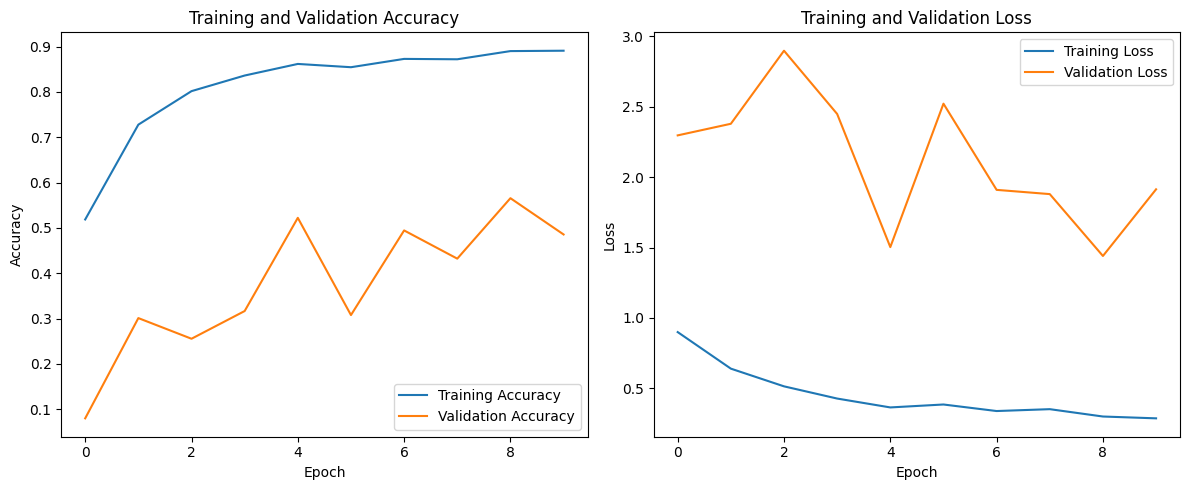

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

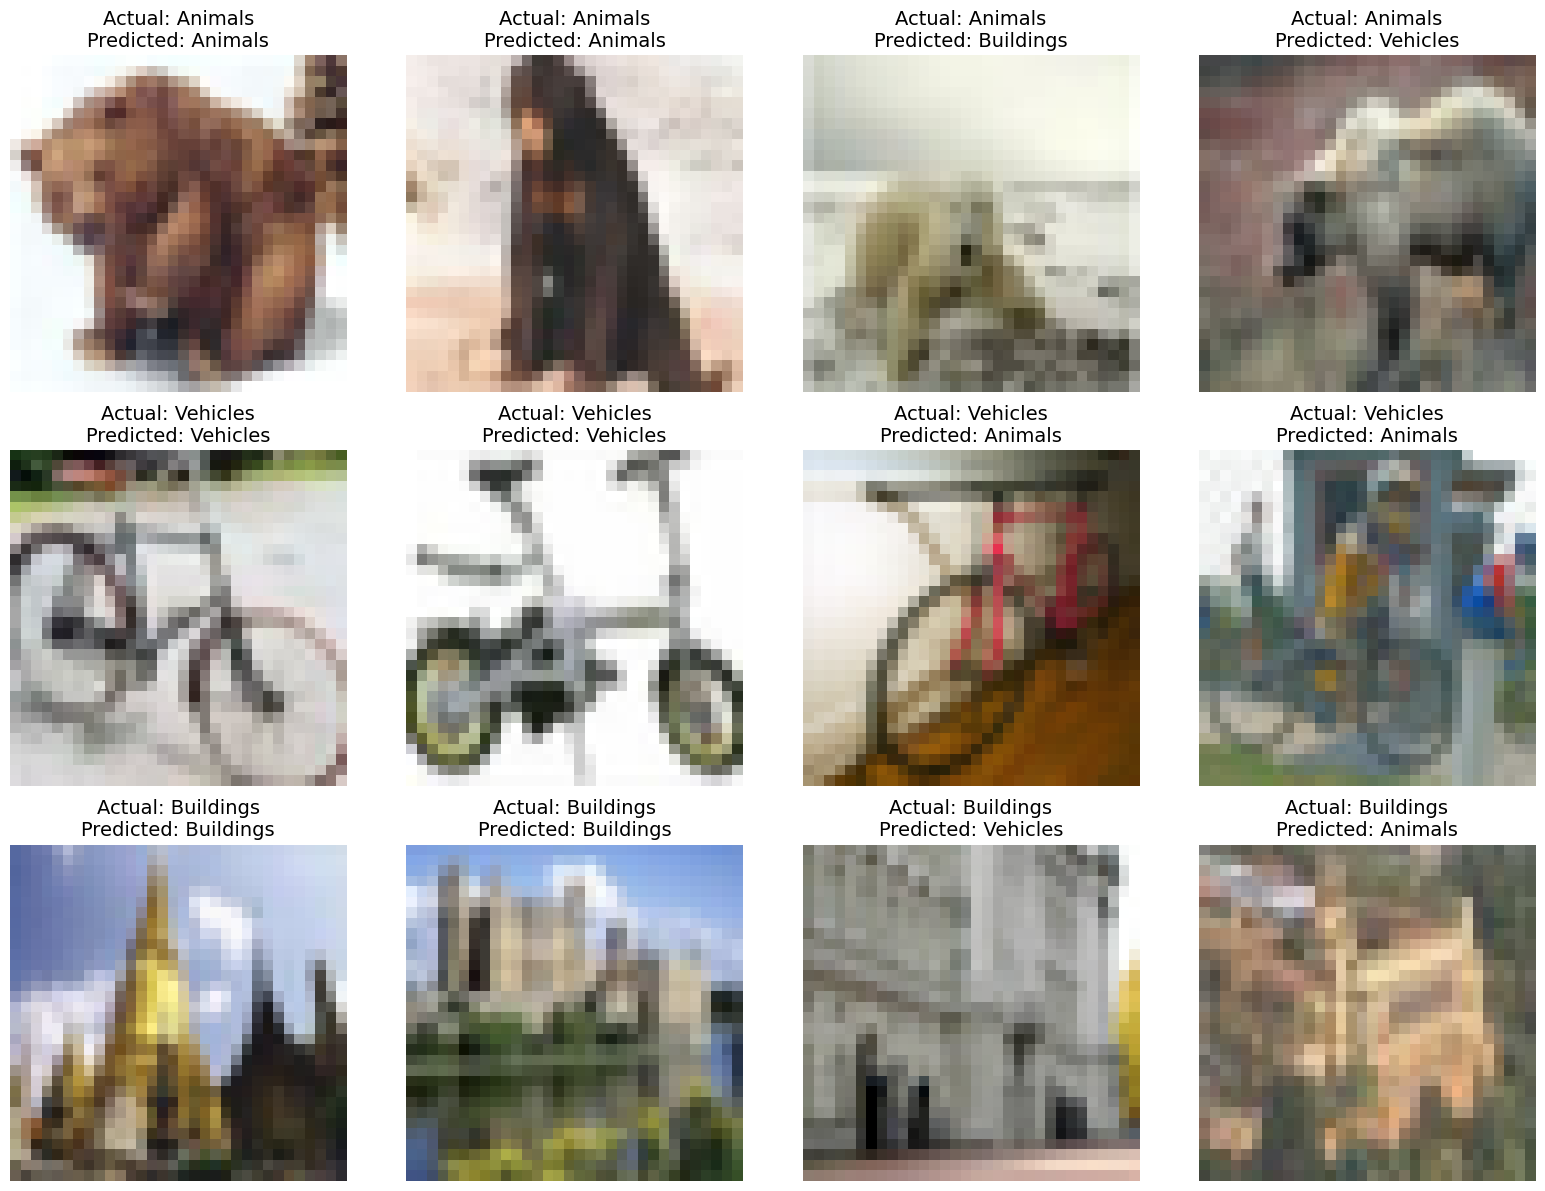

In [ ]:
selected = []

for category in range(3):
    correct = np.where((Y_test == category) & (Y_pred_classes == category))[0]
    incorrect = np.where((Y_test == category) & (Y_pred_classes != category))[0]

    selected.extend(correct[:2])
    selected.extend(incorrect[:2])

plt.figure(figsize=(16, 12))

for j, i in enumerate(selected):
    plt.subplot(3, 4, j + 1)

    plt.imshow(X_test[i], interpolation='nearest')

    actual = category_names[Y_test[i]]
    predicted = category_names[Y_pred_classes[i]]

    plt.title(
        f"Actual: {actual}\nPredicted: {predicted}",
        fontsize=14
    )
    plt.axis('off')

plt.tight_layout()
plt.savefig("final_sample_predictions.png", dpi=300, bbox_inches='tight')
plt.show()

In [4]:
import numpy as np
import matplotlib.pyplot as plt


169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 2526s 15us/step


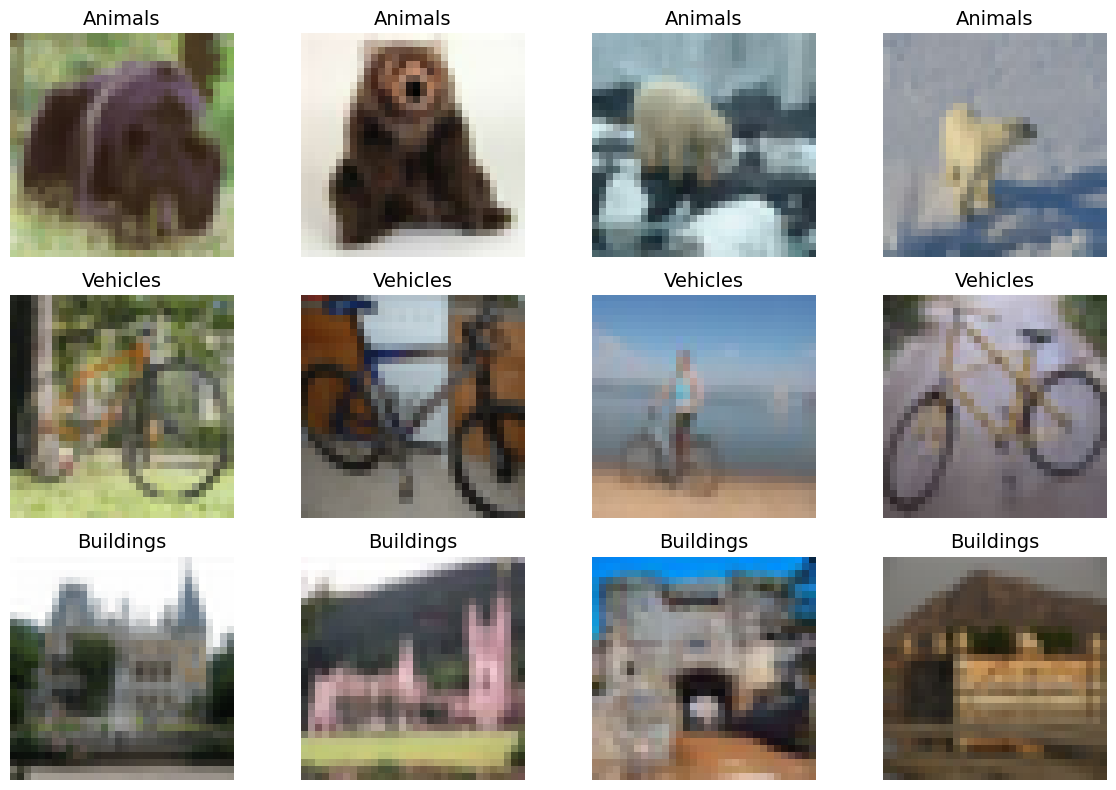

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# CIFAR-100 class names
class_names = [
    'apple', 'aquarium_fish', 'baby', 'bear', 'beaver',
    'bed', 'bee', 'beetle', 'bicycle', 'bottle',
    'bowl', 'boy', 'bridge', 'bus', 'butterfly',
    'camel', 'can', 'castle', 'caterpillar', 'cattle',
    'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach',
    'couch', 'crab', 'crocodile', 'cup', 'dinosaur',
    'dolphin', 'elephant', 'flatfish', 'forest', 'fox',
    'girl', 'hamster', 'house', 'kangaroo', 'keyboard',
    'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard',
    'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain',
    'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid',
    'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree',
    'plain', 'plate', 'poppy', 'porcupine', 'possum',
    'rabbit', 'raccoon', 'ray', 'road', 'rocket',
    'rose', 'sea', 'seal', 'shark', 'shrew',
    'skunk', 'skyscraper', 'snail', 'snake', 'spider',
    'squirrel', 'streetcar', 'sunflower', 'sweet_pepper',
    'table', 'tank', 'telephone', 'television', 'tiger',
    'tractor', 'train', 'trout', 'tulip', 'turtle',
    'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman',
    'worm'
]

animal_ids = [class_names.index(x) for x in ['bear', 'dolphin', 'fox']]
vehicle_ids = [class_names.index(x) for x in ['bicycle', 'bus', 'motorcycle']]
building_ids = [class_names.index(x) for x in ['castle', 'house', 'skyscraper']]

category_names = ['Animals', 'Vehicles', 'Buildings']

# Reload original CIFAR-100 training data
(x_original, y_original), _ = tf.keras.datasets.cifar100.load_data(label_mode='fine')

# Create labels for the three categories
X_visual = []
Y_visual = []

for category, class_ids in enumerate([animal_ids, vehicle_ids, building_ids]):
    for class_id in class_ids:
        indices = np.where(y_original.flatten() == class_id)[0]
        X_visual.append(x_original[indices])
        Y_visual.extend([category] * len(indices))

X_visual = np.concatenate(X_visual)
Y_visual = np.array(Y_visual)

# Display clean input images
plt.figure(figsize=(12, 8))

for category in range(3):
    indices = np.where(Y_visual == category)[0][:4]

    for j, idx in enumerate(indices):
        position = category * 4 + j + 1
        plt.subplot(3, 4, position)
        plt.imshow(X_visual[idx])
        plt.title(category_names[category], fontsize=14)
        plt.axis('off')

plt.tight_layout()
plt.savefig("input_images.png", dpi=300, bbox_inches='tight')
plt.show()